# Question 1

## Preliminary Data Pre-processing

In [ ]:
# Imports
import pandas as pd
from sklearn import preprocessing
import numpy as np
from itertools import combinations
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('data/Assignment1_Question1.csv')
data.head()


,Obs,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,psa
0,1,-0.579819,2.769459,50,-1.386294,0,-1.386294,6,0,0.65
1,2,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,0.85
2,3,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,0.85
3,4,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,0.85
4,5,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,1.45


In [ ]:
data.describe()

,Obs,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,psa
count,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,49.000000,1.350010,3.652686,63.865979,0.100356,0.216495,-0.179366,6.752577,24.381443,23.739691
std,28.145456,1.178625,0.496631,7.445117,1.450807,0.413995,1.398250,0.722134,28.204035,40.825267
min,1.000000,-1.347074,2.374906,41.000000,-1.386294,0.000000,-1.386294,6.000000,0.000000,0.650000
25%,25.000000,0.512824,3.375880,60.000000,-1.386294,0.000000,-1.386294,6.000000,0.000000,5.650000
50%,49.000000,1.446919,3.623007,65.000000,0.300105,0.000000,-0.798508,7.000000,15.000000,13.350000
75%,73.000000,2.127041,3.878466,68.000000,1.558145,0.000000,1.178655,7.000000,40.000000,21.250000
max,97.000000,3.821004,6.107580,79.000000,2.326302,1.000000,2.904165,9.000000,100.000000,265.850000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Obs      97 non-null     int64  
 1   lcavol   97 non-null     float64
 2   lweight  97 non-null     float64
 3   age      97 non-null     int64  
 4   lbph     97 non-null     float64
 5   svi      97 non-null     int64  
 6   lcp      97 non-null     float64
 7   gleason  97 non-null     int64  
 8   pgg45    97 non-null     int64  
 9   psa      97 non-null     float64
dtypes: float64(5), int64(5)
memory usage: 7.7 KB


In [ ]:
X = data.iloc[:, 1:-1]
psa = data.iloc[:, -1].values
scaler = preprocessing.StandardScaler().fit(X)
X_scaled = scaler.transform(X)

In [ ]:
X.columns

Index(['lcavol', 'lweight', 'age', 'lbph', 'svi', 'lcp', 'gleason', 'pgg45'], dtype='object')

In [ ]:
y = np.log(psa)

In [ ]:
np.mean(y)

2.4783868788058667

In [ ]:
np.exp(np.min(y)) # Verification - should be 0.65

0.65

In [ ]:
np.exp(np.quantile(y, 0.25)) # Verification - should be 5.65

5.650000000000001

In [ ]:
X_scaled_df = pd.DataFrame(X_scaled, columns=data.columns[1:-1])
X_scaled_df.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45
0,-1.645861,-1.787678,-1.872101,-1.030029,-0.525657,-0.867655,-1.047571,-0.868957
1,-1.999313,-0.674124,-0.791989,-1.030029,-0.525657,-0.867655,-1.047571,-0.868957
2,-1.587021,-1.945989,1.368234,-1.030029,-0.525657,-0.867655,0.344407,-0.156155
3,-2.178174,-0.748683,-0.791989,-1.030029,-0.525657,-0.867655,-1.047571,-0.868957
4,-0.510513,-0.445921,-0.251933,-1.030029,-0.525657,-0.867655,-1.047571,-0.868957


In [ ]:
X_scaled.mean(axis=0).round(10)  # mean is 0 +- tiny numerical errors
 

array([-0., -0.,  0., -0., -0.,  0., -0.,  0.])

In [ ]:
X_scaled.std(axis=0) #std is 1

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
linear_response_df = X.join(pd.DataFrame(y, columns=['log_psa']))

In [ ]:
linear_response_df.head()

,lcavol,lweight,age,lbph,svi,lcp,gleason,pgg45,log_psa
0,-0.579819,2.769459,50,-1.386294,0,-1.386294,6,0,-0.430783
1,-0.994252,3.319626,58,-1.386294,0,-1.386294,6,0,-0.162519
2,-0.510826,2.691243,74,-1.386294,0,-1.386294,7,20,-0.162519
3,-1.203973,3.282789,58,-1.386294,0,-1.386294,6,0,-0.162519
4,0.751416,3.432373,62,-1.386294,0,-1.386294,6,0,0.371564


In [ ]:
corr_matrix = pd.DataFrame(linear_response_df).corr().abs()

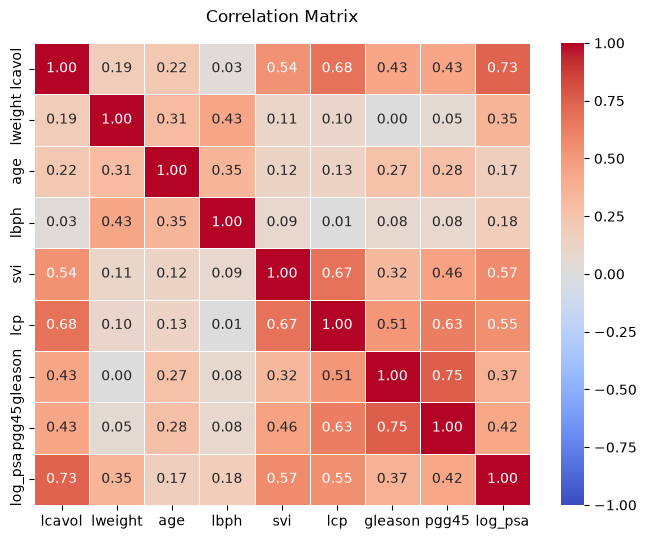

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix", pad=15)
plt.show()

In [ ]:
def fit_all_models(X = X, y = y):
    results = {} # We are to populate it with keys {binary_selected, dimension, features_selected, coeffs, intercept, SSR, dimension}
    reg = LinearRegression()
    scaler = preprocessing.StandardScaler().fit(X)
    X_scaled = scaler.transform(X) # Standardize the features
    n_features = X_scaled.shape[1]
    
    for k in range(1,n_features + 1):
        for features in combinations(range(n_features), k): #all combinations of features of size k
            X_subset = X_scaled[:, features]
            reg.fit(X_subset, y)
            coeffs = reg.coef_
            intercept = reg.intercept_
            SSR = np.sum((y - reg.predict(X_subset)) ** 2)
            binary_selected = [1 if i in features else 0 for i in range(n_features)]
            results[tuple(binary_selected)] = {
                'dimension': k,
                'col_features_selected': features,
                'features_selected': [X.columns[i] for i in features],
                'coeffs': np.round(coeffs, 4),
                'intercept': np.round(intercept, 4),
                'SSR': np.round(SSR, 4)
            }
    binary_selected = [0] * n_features
    SSR = np.sum((y - np.mean(y)) ** 2)
    results[tuple(binary_selected)] = {
    'dimension': 0,
    'col_features_selected': (),
    'features_selected': [],
    'coeffs': np.empty(0),
    'intercept': round(np.mean(y), 4),
    'SSR': round(SSR, 4)
}
    
    return results

In [ ]:
results = fit_all_models(X, y)

In [ ]:
def plot_SSR_vs_dimension(X=X, y=y):
    results = fit_all_models(X, y)
    ssr_by_dimension = {k: {'SSRs': []} for k in range(X.shape[1] + 1)}
    
    for key, value in results.items():
        ssr_by_dimension[value['dimension']]['SSRs'].append(value['SSR'])
    
    dimensions, mean_SSRs, std_SSRs, min_SSRs, max_SSRs = [], [], [], [], []
    
    for dim, ssr_dict in ssr_by_dimension.items():
        if not ssr_dict['SSRs']:
            continue
        dimensions.append(dim)
        mean_SSRs.append(np.mean(ssr_dict['SSRs']))
        std_SSRs.append(np.std(ssr_dict['SSRs']))
        min_SSRs.append(np.min(ssr_dict['SSRs']))
        max_SSRs.append(np.max(ssr_dict['SSRs']))

    plt.figure(figsize=(10, 6))
    # Moyenne connectée (bleu) et Std sous forme de barres d'erreur (orange)
    plt.errorbar(dimensions, mean_SSRs, yerr=std_SSRs, fmt='-o', color='blue', 
                 ecolor='orange', elinewidth=2, capsize=5, label='Mean ± Std')
    
    # Points Min (vert) et Max (rouge) non connectés
    plt.plot(dimensions, min_SSRs, color='green',marker='o', label='Min SSR', zorder=3)
    plt.scatter(dimensions, max_SSRs, color='red', marker='o', label='Max SSR', zorder=3)
    

    
    plt.title('SSR vs Dimension of Model')
    plt.xlabel('Dimension of Model (Number of Features)')
    plt.ylabel('Sum of Squared Residuals (SSR)')
    plt.xticks(range(max(dimensions) + 1))
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

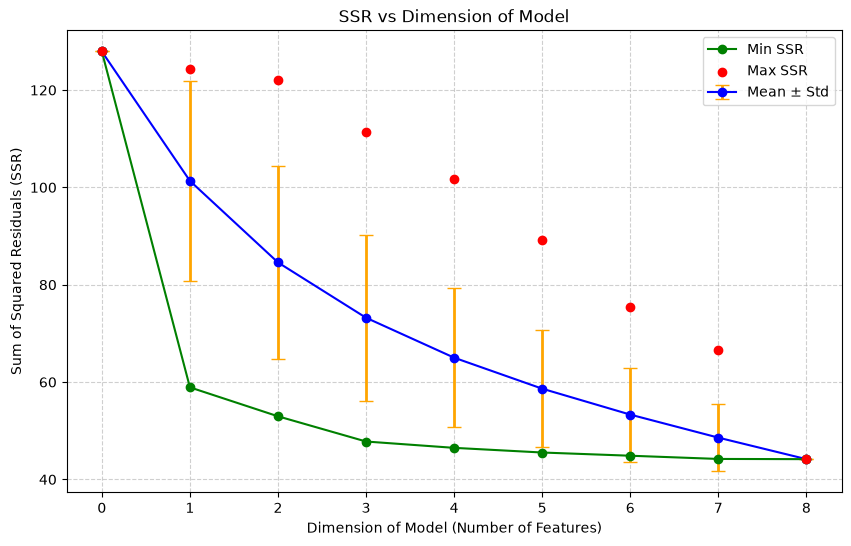

In [ ]:
plot_SSR_vs_dimension()

In [ ]:
import plotly.graph_objects as go
import numpy as np


In [ ]:

def plot_SSR_vs_dimension(X=X, y=y):
    results = fit_all_models(X, y)
    ssr_by_dimension = {k: {'SSRs': []} for k in range(X.shape[1] + 1)}
    
    for key, value in results.items():
        ssr_by_dimension[value['dimension']]['SSRs'].append(value['SSR'])
    
    dimensions, mean_SSRs, std_SSRs, min_SSRs, max_SSRs = [], [], [], [], []
    
    for dim, ssr_dict in ssr_by_dimension.items():
        if not ssr_dict['SSRs']:
            continue
        dimensions.append(dim)
        mean_SSRs.append(np.mean(ssr_dict['SSRs']))
        std_SSRs.append(np.std(ssr_dict['SSRs']))
        min_SSRs.append(np.min(ssr_dict['SSRs']))
        max_SSRs.append(np.max(ssr_dict['SSRs']))

    fig = go.Figure()

    # Points Min (vert), non connectés
    fig.add_trace(go.Scatter(
        x=dimensions, y=min_SSRs, 
        mode='lines + markers', 
        marker=dict(color='green', size=8), 
        name='Min SSR'
    ))
    
    # Points Max (rouge), non connectés
    fig.add_trace(go.Scatter(
        x=dimensions, y=max_SSRs, 
        mode='markers', 
        marker=dict(color='red', size=8), 
        name='Max SSR'
    ))

    # Moyenne (bleu) connectée avec barres d'erreur (orange)
    fig.add_trace(go.Scatter(
        x=dimensions, y=mean_SSRs, 
        mode='lines+markers',
        line=dict(color='blue', width=2),
        error_y=dict(type='data', array=std_SSRs, color='orange', thickness=2, width=6),
        name='Mean ± Std'
    ))

    fig.update_layout(
        title='SSR vs Dimension of Model',
        xaxis_title='Dimension of Model (Number of Features)',
        yaxis_title='Sum of Squared Residuals (SSR)',
        xaxis=dict(tickmode='linear', tick0=0, dtick=1), # Force l'affichage de tous les entiers
        template="plotly_white"
    )

    fig.show()  # Use "notebook_connected" for Jupyter Notebook or "browser" for standalone 

In [ ]:
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)
plot_SSR_vs_dimension()

The (best) SSR is reduced substantially when adding a dimension, up to $d = 3$. After that, the SSR goes down very slightly, up to $d = 7$. Yielding the full model (compared to using 7 dimensions) barely decreases. 
<br>The results suggest that we could select a 3-features model, which seems to be the best trade off between model parcimony and explaining power.

## 1.2

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector

In [ ]:
def mallows_cp(X=X, y=y):
    results = fit_all_models(X, y)
    n_datapoints = X.shape[0]
    n_features = X.shape[1]
    full_model_features = tuple([1] * n_features)
    SSR_full = results[full_model_features]['SSR']
    sigma_squared = SSR_full / (n_datapoints - n_features - 1) # unbiased estimate of variance of residuals for the full model
    for key, value in results.items():
        mallows_cp = (value['SSR'] / sigma_squared) - (n_datapoints - 2 * value['dimension'])
        results[key]['mallows_cp'] = np.round(mallows_cp, 4)
    return results
    

In [ ]:
mallows_results = mallows_cp(X, y)
mallows_results

{(1, 0, 0, 0, 0, 0, 0, 0): {'dimension': 1,
  'col_features_selected': (0,),
  'features_selected': ['lcavol'],
  'coeffs': array([0.8434]),
  'intercept': 2.4784,
  'SSR': 58.9148,
  'mallows_cp': 22.3944},
 (0, 1, 0, 0, 0, 0, 0, 0): {'dimension': 1,
  'col_features_selected': (1,),
  'features_selected': ['lweight'],
  'coeffs': array([0.4067]),
  'intercept': 2.4784,
  'SSR': 111.8766,
  'mallows_cp': 127.9269},
 (0, 0, 1, 0, 0, 0, 0, 0): {'dimension': 1,
  'col_features_selected': (2,),
  'features_selected': ['age'],
  'coeffs': array([0.1948]),
  'intercept': 2.4784,
  'SSR': 124.2385,
  'mallows_cp': 152.5593},
 (0, 0, 0, 1, 0, 0, 0, 0): {'dimension': 1,
  'col_features_selected': (3,),
  'features_selected': ['lbph'],
  'coeffs': array([0.2065]),
  'intercept': 2.4784,
  'SSR': 123.7819,
  'mallows_cp': 151.6495},
 (0, 0, 0, 0, 1, 0, 0, 0): {'dimension': 1,
  'col_features_selected': (4,),
  'features_selected': ['svi'],
  'coeffs': array([0.6502]),
  'intercept': 2.4784,
  'SS

In [ ]:
def select_forward_best_model(X=X, y=y):
    def select_forward_best_model_by_dimension(X=X, y=y):
        mallows_results = mallows_cp(X, y)
        n_features = X.shape[1]
        best_submodels = []
        for k in range(n_features + 1):
            # Filter results for models of dimension k
            models_of_dimension_k = {key: value for key, value in mallows_results.items() if value['dimension'] == k}
            
            # Find the model with the minimum Mallows' Cp for this dimension
            best_model_key = min(models_of_dimension_k, key=lambda key: models_of_dimension_k[key]['SSR'])
            best_submodels.append(models_of_dimension_k[best_model_key])
            
        return mallows_results, best_submodels
    mallows_results, best_submodels = select_forward_best_model_by_dimension(X, y)
    best_model = min(best_submodels, key=lambda model: model['mallows_cp'])
    return best_model, best_submodels, mallows_results

In [ ]:
best_model, best_submodels, mallows_results = select_forward_best_model(X, y)
best_model_df = pd.DataFrame([best_model])
best_model_df["coeffs"] = best_model_df["coeffs"].apply(lambda x: np.round(x, decimals=2))
best_submodel_df = pd.DataFrame(best_submodels)
best_submodel_df["coeffs"] = best_submodel_df["coeffs"].apply(lambda x: np.round(x, decimals=2))


In [ ]:
best_model_df

,dimension,col_features_selected,features_selected,coeffs,intercept,SSR,mallows_cp
0,4,"(0, 1, 3, 4)","[lcavol, lweight, lbph, svi]","[0.64, 0.19, 0.13, 0.29]",2.4784,46.4849,3.6265


In [ ]:
best_submodel_df

,dimension,col_features_selected,features_selected,coeffs,intercept,SSR,mallows_cp
0,0,(),[],[],2.4784,127.9177,157.8906
1,1,"(0,)",[lcavol],[0.84],2.4784,58.9148,22.3944
2,2,"(0, 1)","[lcavol, lweight]","[0.79, 0.25]",2.4784,52.9664,12.5416
3,3,"(0, 1, 4)","[lcavol, lweight, svi]","[0.65, 0.25, 0.27]",2.4784,47.7850,4.2170
4,4,"(0, 1, 3, 4)","[lcavol, lweight, lbph, svi]","[0.64, 0.19, 0.13, 0.29]",2.4784,46.4849,3.6265
5,5,"(0, 1, 2, 3, 4)","[lcavol, lweight, age, lbph, svi]","[0.66, 0.21, -0.11, 0.16, 0.3]",2.4784,45.5257,3.7151
6,6,"(0, 1, 2, 3, 4, 7)","[lcavol, lweight, age, lbph, svi, pgg45]","[0.64, 0.22, -0.13, 0.15, 0.26, 0.1]",2.4784,44.8667,4.4020
7,7,"(0, 1, 2, 3, 4, 5, 7)","[lcavol, lweight, age, lbph, svi, lcp, pgg45]","[0.69, 0.22, -0.14, 0.16, 0.31, -0.15, 0.15]",2.4784,44.2044,5.0823
8,8,"(0, 1, 2, 3, 4, 5, 6, 7)","[lcavol, lweight, age, lbph, svi, lcp, gleason...","[0.69, 0.22, -0.15, 0.15, 0.32, -0.15, 0.03, 0...",2.4784,44.1631,7.0000


In [ ]:
sfs = SequentialFeatureSelector(
    estimator=LinearRegression(),
    n_features_to_select="auto",
    direction="forward",
    cv=5,                   
    scoring="neg_mean_squared_error"         # MSE 
)

def select_forward_best_model_sfs(X=X, y=y, sfs = sfs):
    scaler = preprocessing.StandardScaler().fit(X)
    X_scaled = scaler.transform(X) # Standardize the features
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
    sfs.fit(X_scaled_df, y)
    return sfs

In [ ]:
sfs = select_forward_best_model_sfs(X, y, sfs)

In [ ]:
# 1. Extract the selected features
X_selected = sfs.transform(X_scaled)

# 2. Train your final model on the selected features
best_model = LinearRegression().fit(X_selected, y)

# Optional: see which features were chosen (boolean mask or names if X is a DataFrame)
selected_mask = sfs.get_support()

/Users/sachacohen/opt/anaconda3/envs/math782/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SequentialFeatureSelector was fitted with feature names
  warnings.warn(


In [ ]:
sfs_backward = SequentialFeatureSelector(
    estimator=LinearRegression(),
    n_features_to_select="auto",
    direction="backward",
    cv=5,                   
    scoring="neg_mean_squared_error"         # MSE
)
sfs_backward = select_forward_best_model_sfs(X, y, sfs_backward)
# 1. Extract the selected features
X_selected = sfs_backward.transform(X_scaled)

# 2. Train your final model on the selected features
best_model = LinearRegression().fit(X_selected, y)

# Optional: see which features were chosen (boolean mask or names if X is a DataFrame)
selected_mask = sfs_backward.get_support()


/Users/sachacohen/opt/anaconda3/envs/math782/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SequentialFeatureSelector was fitted with feature names
  warnings.warn(


In [ ]:
selected_mask

array([ True,  True, False, False,  True,  True, False, False])

# Question 2: simulation study

For each design matrix, `Y_samples` is an explicit **100 samples by 50 observations** array. Every candidate model retains its intercept. All 32 predictor subsets compete for the minimum Cp, AIC, BIC, leave-one-out CV, GCV, 5-fold CV, and 10-fold CV.

`selected_models` records the winner for each sample and criterion; `selection_percentages` contains all models, including those selected zero times. The three displayed tables contain the true model (**intercept + x2 + x4**) and all models that include it, as requested in the assignment. Values are percentages of all 100 samples, so the filtered columns need not sum to 100%. `simulation_results[rho]` retains the responses and full results for each correlation. The simulation seed is 782, and CV uses the same fixed folds for every candidate.

In [1]:
import numpy as np
import pandas as pd
from itertools import combinations

# Each row is one simulated sample; each column is one observation.
from sklearn.model_selection import KFold

R = 100
n = 50
beta = np.array([1.5, 0.0, 2.0, 0.0, 1.5, 0.0])
CRITERIA = ('Mallows_Cp', 'AIC', 'BIC', 'CV', 'GCV', 'CV_5', 'CV_10')


def generate_response_samples(R, n, filename, random_state=None):
    """Return the full design and an explicit (R, n) array of responses.

    Y_samples[r, i] is observation i in simulated sample r. The supplied
    design includes the intercept column; independent N(0, 1) errors are
    generated for every observation in every sample.
    """
    X_design = pd.read_csv(filename).to_numpy(dtype=float)
    if R < 1 or X_design.shape != (n, len(beta)):
        raise ValueError(
            f"R must be positive and the design must have shape {(n, len(beta))}; "
            f"got R={R}, shape={X_design.shape}."
        )
    if not np.allclose(X_design[:, 0], 1):
        raise ValueError('The first design column must be the intercept (all ones).')

    rng = np.random.default_rng(random_state)
    mean_response = X_design @ beta
    errors = rng.normal(loc=0.0, scale=1.0, size=(R, n))
    Y_samples = mean_response[np.newaxis, :] + errors
    return X_design, Y_samples

In [2]:
def fit_all_models_criteria(X_design, y, cv=(5, 10)):
    """Score all predictor subsets, always fitting an intercept.

    X_design contains predictors only. Feature tuples use zero-based indices.
    CV is leave-one-out CV, computed exactly from OLS residuals and leverage.
    CV_d uses d fixed, contiguous folds, shared by all candidate models and
    all response samples. Scores are mean squared errors over observations.
    Set cv=None to omit the additional fold-based scores.
    """
    X_design = np.asarray(X_design, dtype=float)
    y = np.asarray(y, dtype=float)
    if X_design.ndim != 2 or y.shape != (X_design.shape[0],):
        raise ValueError('Expected a predictor matrix and one response per observation.')
    if not np.isfinite(X_design).all() or not np.isfinite(y).all():
        raise ValueError('Predictors and responses must be finite.')
    n_samples, n_features = X_design.shape
    full_design = np.column_stack((np.ones(n_samples), X_design))
    full_parameters = n_features + 1
    if n_samples <= full_parameters:
        raise ValueError('The full model must have positive residual degrees of freedom.')
    if np.linalg.matrix_rank(full_design) != full_parameters:
        raise ValueError('The full design must have linearly independent columns.')
    full_residuals = y - full_design @ np.linalg.lstsq(full_design, y, rcond=None)[0]
    sigma_squared = np.sum(full_residuals ** 2) / (n_samples - full_parameters)
    if sigma_squared <= 0:
        raise ValueError('The full-model variance estimate must be positive.')

    fold_counts = () if cv is None else ((cv,) if isinstance(cv, int) else tuple(cv))
    folds = {d: list(KFold(n_splits=d, shuffle=False).split(X_design))
             for d in fold_counts}
    model_results = {}
    for k in range(n_features + 1):
        for features in combinations(range(n_features), k):
            # The ones column also makes the empty subset an intercept-only fit.
            design = full_design[:, [0] + [i + 1 for i in features]]
            coefficients = np.linalg.lstsq(design, y, rcond=None)[0]
            residuals = y - design @ coefficients
            ssr = np.sum(residuals ** 2)
            parameters = k + 1
            q, _ = np.linalg.qr(design, mode='reduced')
            leverage = np.sum(q ** 2, axis=1)
            result = {
                'dimension': k,
                'features_selected': features,
                'SSR': ssr,
                'Mallows_Cp': ssr / sigma_squared - n_samples + 2 * parameters,
                'AIC': n_samples * np.log(ssr / n_samples) + 2 * parameters,
                'BIC': n_samples * np.log(ssr / n_samples) + parameters * np.log(n_samples),
                'CV': np.mean((residuals / (1 - leverage)) ** 2),
                'GCV': (ssr / n_samples) / (1 - parameters / n_samples) ** 2,
            }
            for d, splits in folds.items():
                held_out_ssr = 0.0
                for train, test in splits:
                    fold_design = design[train]
                    if np.linalg.matrix_rank(fold_design) != parameters:
                        raise ValueError('A CV training design is rank deficient.')
                    fold_coefficients = np.linalg.lstsq(fold_design, y[train], rcond=None)[0]
                    held_out_ssr += np.sum((y[test] - design[test] @ fold_coefficients) ** 2)
                result[f'CV_{d}'] = held_out_ssr / n_samples
            model_results[features] = result
    return model_results

In [3]:
def select_best_submodels(X_design, Y_samples, criteria=CRITERIA):
    """Return per-sample winners and percentages for every candidate model.

    All criteria are minimized over all 2**p subsets. Exact ties select the
    smaller model, then the first feature tuple. Percentages use all samples
    as the denominator, even when the summary is subsequently filtered.
    """
    X_design = np.asarray(X_design, dtype=float)
    Y_samples = np.asarray(Y_samples, dtype=float)
    if X_design.ndim != 2 or Y_samples.ndim != 2:
        raise ValueError('X_design and Y_samples must both be two-dimensional arrays.')
    if Y_samples.shape[0] == 0 or Y_samples.shape[1] != X_design.shape[0]:
        raise ValueError('Y_samples must have shape (R, number of observations), with R > 0.')
    if not criteria or any(criterion not in CRITERIA for criterion in criteria):
        raise ValueError(f'Choose one or more criteria from {CRITERIA}.')

    winners = []
    for sample in Y_samples:
        scores = fit_all_models_criteria(X_design, sample)
        winners.append({
            criterion: min(scores, key=lambda features: (
                scores[features][criterion], len(features), features
            ))
            for criterion in criteria
        })
    selected_models = pd.DataFrame(winners)
    selected_models.index = pd.RangeIndex(1, len(winners) + 1, name='sample')

    rows = []
    for k in range(X_design.shape[1] + 1):
        for features in combinations(range(X_design.shape[1]), k):
            row = {
                'model': 'Intercept' + ''.join(f' + x{i + 1}' for i in features),
                'features_selected': features,
                'dimension': k,
            }
            for criterion in criteria:
                row[criterion] = 100 * sum(
                    winner == features for winner in selected_models[criterion]
                ) / len(winners)
            rows.append(row)
    selection_percentages = pd.DataFrame(rows).set_index('model')
    return selected_models, selection_percentages

In [4]:
# Generate and select independently for each of the three supplied designs.
# The seed makes the simulation reproducible when the cells are rerun.
rng = np.random.default_rng(782)
true_features = tuple(np.flatnonzero(beta[1:]))  # (1, 3), i.e. x2 and x4
simulation_results = {}
selection_tables = {}
for rho, design_name in [(0.0, 'I'), (0.5, 'II'), (0.75, 'III')]:
    full_design, Y_samples = generate_response_samples(
        R, n, f'data/Assignment1_Question2_X_{design_name}.csv', random_state=rng
    )
    X_design = full_design[:, 1:]  # Intercepts are added to every candidate fit.
    selected_models, selection_percentages = select_best_submodels(X_design, Y_samples)
    contains_true_model = selection_percentages['features_selected'].apply(
        lambda features: set(true_features).issubset(features)
    )
    report_table = selection_percentages.loc[contains_true_model, list(CRITERIA)].copy()
    report_table.columns.name = 'Selection percentage (%)'
    selection_tables[rho] = report_table
    simulation_results[rho] = {
        'X_design': X_design,
        'Y_samples': Y_samples,
        'selected_models': selected_models,
        'selection_percentages': selection_percentages,
        'report_table': report_table,
    }

In [5]:
from IPython.display import display

for rho, table in selection_tables.items():
    print(f"Correlation rho = {rho}; {R} samples of {n} observations")
    display(table)

Correlation rho = 0.0; 100 samples of 50 observations


Selection percentage (%),Mallows_Cp,AIC,BIC,CV,GCV,CV_5,CV_10
model,,,,,,,
Intercept + x2 + x4,63.0,60.0,86.0,61.0,62.0,48.0,56.0
Intercept + x1 + x2 + x4,9.0,10.0,5.0,10.0,10.0,11.0,10.0
Intercept + x2 + x3 + x4,7.0,6.0,5.0,9.0,7.0,11.0,10.0
Intercept + x2 + x4 + x5,12.0,12.0,2.0,12.0,12.0,14.0,12.0
Intercept + x1 + x2 + x3 + x4,3.0,4.0,0.0,3.0,3.0,5.0,3.0
Intercept + x1 + x2 + x4 + x5,2.0,3.0,1.0,2.0,2.0,2.0,4.0
Intercept + x2 + x3 + x4 + x5,4.0,5.0,1.0,3.0,4.0,8.0,5.0
Intercept + x1 + x2 + x3 + x4 + x5,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Correlation rho = 0.5; 100 samples of 50 observations


Selection percentage (%),Mallows_Cp,AIC,BIC,CV,GCV,CV_5,CV_10
model,,,,,,,
Intercept + x2 + x4,66.0,60.0,88.0,64.0,63.0,56.0,61.0
Intercept + x1 + x2 + x4,7.0,11.0,3.0,6.0,9.0,11.0,8.0
Intercept + x2 + x3 + x4,10.0,10.0,5.0,12.0,10.0,11.0,10.0
Intercept + x2 + x4 + x5,11.0,12.0,4.0,13.0,12.0,13.0,14.0
Intercept + x1 + x2 + x3 + x4,1.0,1.0,0.0,2.0,1.0,2.0,1.0
Intercept + x1 + x2 + x4 + x5,1.0,2.0,0.0,1.0,1.0,6.0,5.0
Intercept + x2 + x3 + x4 + x5,4.0,4.0,0.0,2.0,4.0,1.0,1.0
Intercept + x1 + x2 + x3 + x4 + x5,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Correlation rho = 0.75; 100 samples of 50 observations


Selection percentage (%),Mallows_Cp,AIC,BIC,CV,GCV,CV_5,CV_10
model,,,,,,,
Intercept + x2 + x4,57.0,54.0,82.0,58.0,55.0,52.0,49.0
Intercept + x1 + x2 + x4,13.0,14.0,5.0,13.0,14.0,14.0,13.0
Intercept + x2 + x3 + x4,13.0,14.0,7.0,14.0,14.0,14.0,15.0
Intercept + x2 + x4 + x5,9.0,10.0,5.0,9.0,9.0,6.0,14.0
Intercept + x1 + x2 + x3 + x4,3.0,3.0,1.0,1.0,3.0,3.0,3.0
Intercept + x1 + x2 + x4 + x5,3.0,3.0,0.0,3.0,3.0,8.0,5.0
Intercept + x2 + x3 + x4 + x5,1.0,1.0,0.0,2.0,1.0,3.0,1.0
Intercept + x1 + x2 + x3 + x4 + x5,1.0,1.0,0.0,0.0,1.0,0.0,0.0
